# Final Project: American Community Survey County Data Analysis
By: Maya Amman, mkz3cr
## Main Question
**Is there a relationship between the percentage of professional workers and median household income across U.S. counties?**

This question helps us understand whether higher levels of education are associated with higher income across counties.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("acs2017_county_data.csv")

df.shape
df.head()
df.columns
df.describe()

,CountyId,TotalPop,Men,Women,Hispanic,White,Black,Native,Asian,Pacific,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
count,3220.000000,3.220000e+03,3.220000e+03,3.220000e+03,3220.000000,3220.000000,3220.000000,3220.000000,3220.000000,3220.000000,...,3220.000000,3220.000000,3220.000000,3220.000000,3.220000e+03,3220.000000,3220.000000,3220.000000,3220.000000,3220.000000
mean,31393.605280,1.007681e+05,4.958781e+04,5.118032e+04,11.296584,74.920186,8.681957,1.768416,1.289379,0.083416,...,3.244472,1.598696,4.736894,23.474534,4.709295e+04,74.863323,17.086118,7.772733,0.278820,6.665590
std,16292.078954,3.244996e+05,1.593212e+05,1.652164e+05,19.342522,23.056700,14.333571,7.422946,2.716191,0.709277,...,3.891510,1.678232,3.073484,5.687241,1.558159e+05,7.647916,6.390868,3.855454,0.448073,3.772612
min,1001.000000,7.400000e+01,3.900000e+01,3.500000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.100000,3.900000e+01,31.100000,4.400000,0.000000,0.000000,0.000000
25%,19032.500000,1.121350e+04,5.645500e+03,5.553500e+03,2.100000,63.500000,0.600000,0.100000,0.200000,0.000000,...,1.400000,0.800000,2.900000,19.600000,4.573000e+03,71.200000,12.700000,5.200000,0.100000,4.475000
50%,30024.000000,2.584750e+04,1.287900e+04,1.299350e+04,4.100000,83.600000,2.000000,0.300000,0.600000,0.000000,...,2.300000,1.300000,4.100000,23.200000,1.061150e+04,76.100000,15.900000,6.800000,0.200000,6.100000
75%,46105.500000,6.660825e+04,3.301725e+04,3.359375e+04,10.000000,92.800000,9.500000,0.600000,1.200000,0.100000,...,3.825000,1.900000,5.800000,27.000000,2.874725e+04,80.200000,19.900000,9.200000,0.300000,8.000000
max,72153.000000,1.010572e+07,4.979641e+06,5.126081e+06,100.000000,100.000000,86.900000,90.300000,41.800000,33.700000,...,59.200000,43.200000,33.000000,45.100000,4.805817e+06,88.800000,64.800000,38.000000,8.000000,40.900000


## Dataset Overview

The dataset contains 3,220 observations (counties) and multiple variables describing demographic and economic characteristics.

Each row represents a U.S. county, and each column represents a feature such as population, race distribution, income, poverty, and employment type.

From the summary statistics, we can observe that:

- The average median household income is about $48,995, with values ranging from $11,680 to $129,588.
- The average poverty rate is about 16.8%, with some counties reaching over 65%.
- The percentage of professional workers averages around 31.5%, but varies across counties.

The dataset shows substantial variation across counties, which makes it appropriate for analyzing relationships between variables such as employment structure and income.

In [ ]:
high_income_counter = 0

for i in range(len(df)):

    income = df.loc[i, "Income"]
    professional = df.loc[i, "Professional"]

    if pd.notna(income) and pd.notna(professional):

        if professional > 35 and income > 50000:
            high_income_counter = high_income_counter + 1

print("Number of counties with high professional jobs and high income:", high_income_counter)

Number of counties with high professional jobs and high income: 583


## Exploring High Professional Employment and Income

This loop iterates through each county in the dataset and counts how many counties have **both a high percentage of professional workers** (greater than 35%) and a **high median household income** (greater than $50,000).

The result shows that **583 counties** meet both conditions.

This suggests that there is a meaningful number of counties where higher professional employment and higher income occur together. While this does not prove a causal relationship, it provides initial evidence that these two variables may be positively related.

This result supports further analysis using visualization and regression to better understand the strength and direction of the relationship.

In [ ]:
def average_value_by_state(data, column_name):

    #This function takes a dataset and a numeric column name.
    #It returns the average value of that column for each state.

    state_average = data.groupby("State")[column_name].mean()
    return state_average


income_by_state = average_value_by_state(df, "Income")
print(income_by_state)
professional_by_state = average_value_by_state(df, "Professional")
print(professional_by_state)

State
Alabama                 40271.402985
Alaska                  66425.448276
Arizona                 45816.666667
Arkansas                39025.080000
California              61046.758621
Colorado                54353.562500
Connecticut             74496.000000
Delaware                61294.666667
District of Columbia    77649.000000
Florida                 47144.328358
Georgia                 43268.786164
Hawaii                  68663.000000
Idaho                   46171.931818
Illinois                52930.382353
Indiana                 51877.402174
Iowa                    53436.080808
Kansas                  50022.571429
Kentucky                41470.491667
Louisiana               42654.078125
Maine                   49680.812500
Maryland                72541.166667
Massachusetts           71030.714286
Michigan                47530.518072
Minnesota               57530.000000
Mississippi             37018.719512
Missouri                44435.304348
Montana                 47746.75

This function calculates the average value of a selected variable for each state. I called it twice, once for **median household income** and once for the **percentage of professional workers**, to compare state-level patterns related to my main question.

In [ ]:
income_array = df["Income"].values

print("Mean income:", np.mean(income_array))
print("Highest income:", np.max(income_array))
print("First income value:", income_array[0])
above_average_income = income_array[income_array > np.mean(income_array)]

print("Number of counties with income above the average:", len(above_average_income))

Mean income: 48994.966770186336
Highest income: 129588
First income value: 55317
Number of counties with income above the average: 1471


## NumPy Array Indexing: Income Values

In this step, I converted the `Income` column into a NumPy array so I could work directly with the income values.

The average median household income across counties is about $48,995, while the highest county income is $129,588. The first income value in the array is $55,317, showing how NumPy indexing can be used to access a specific value.

Using a condition to filter the income values, I found that 1,471 counties have median household incomes above the dataset average. Since the dataset has 3,220 counties, fewer than half of the counties are above the average income, which suggests that some very high-income counties may be pulling the average upward.

In [ ]:
state_income_dictionary = {}

for state in df["State"].unique():
    state_data = df[df["State"] == state]
    average_income = state_data["Income"].mean()
    state_income_dictionary[state] = average_income

print(state_income_dictionary)
highest_state = ""
highest_income = 0

for state in state_income_dictionary:
    if state_income_dictionary[state] > highest_income:
        highest_income = state_income_dictionary[state]
        highest_state = state

print("State with the highest average county income:", highest_state)
print("Average county income:", highest_income)

{'Alabama': np.float64(40271.40298507463), 'Alaska': np.float64(66425.44827586207), 'Arizona': np.float64(45816.666666666664), 'Arkansas': np.float64(39025.08), 'California': np.float64(61046.75862068965), 'Colorado': np.float64(54353.5625), 'Connecticut': np.float64(74496.0), 'Delaware': np.float64(61294.666666666664), 'District of Columbia': np.float64(77649.0), 'Florida': np.float64(47144.32835820896), 'Georgia': np.float64(43268.78616352201), 'Hawaii': np.float64(68663.0), 'Idaho': np.float64(46171.931818181816), 'Illinois': np.float64(52930.382352941175), 'Indiana': np.float64(51877.40217391304), 'Iowa': np.float64(53436.080808080806), 'Kansas': np.float64(50022.57142857143), 'Kentucky': np.float64(41470.49166666667), 'Louisiana': np.float64(42654.078125), 'Maine': np.float64(49680.8125), 'Maryland': np.float64(72541.16666666667), 'Massachusetts': np.float64(71030.71428571429), 'Michigan': np.float64(47530.51807228916), 'Minnesota': np.float64(57530.0), 'Mississippi': np.float64(3

## Dictionary Manipulation: Average County Income by State

In this step, I created a dictionary where each state is a key and the value is the average county-level median household income for that state. This helps summarize the county data at the state level.

After building the dictionary, I looped through it to identify which state or district had the highest average county income. The result shows that the **District of Columbia had the highest average county income at $77,649**.

This step is useful because it shows that income varies meaningfully by geography. It also supports the broader analysis by showing that **county income is not evenly distributed across states**, so location may be another factor influencing income beyond professional employment.

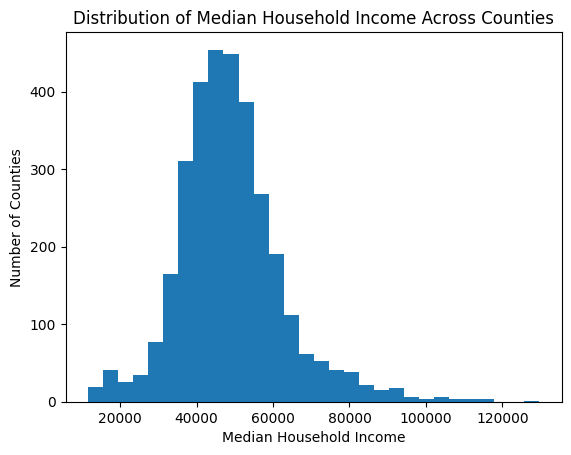

In [ ]:
fig, ax = plt.subplots()

ax.hist(df["Income"], bins=30)

ax.set_xlabel("Median Household Income")
ax.set_ylabel("Number of Counties")
ax.set_title("Distribution of Median Household Income Across Counties")

plt.show()

## Income Distribution

I chose a histogram because median household income is a numeric variable, and a histogram is useful for showing how values are distributed across counties.

The histogram shows that the distribution of median household income is right-skewed. Most counties are concentrated between approximately $35,000 and $60,000, while a smaller number of counties have much higher incomes, creating a long tail on the right side.

This indicates that income is not evenly distributed across counties, and that a few high-income counties may be increasing the overall average. Understanding this distribution is important when interpreting the relationship between income and other variables in the dataset.


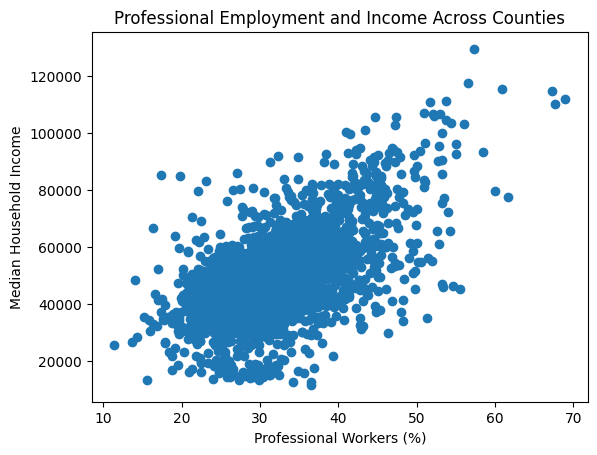

In [ ]:
fig, ax = plt.subplots()

ax.scatter(df["Professional"], df["Income"])

ax.set_xlabel("Professional Workers (%)")
ax.set_ylabel("Median Household Income")
ax.set_title("Professional Employment and Income Across Counties")

plt.show()

## Relationship Between Professional Employment and Income

I chose a scatter plot because both the percentage of professional workers and median household income are numeric variables. A scatter plot is useful for visualizing the relationship between two numeric variables.

The plot shows a positive relationship between professional employment and median household income. As the percentage of professional workers increases, income generally tends to increase as well.

The points form an **upward trend**, although there is some spread, indicating that the relationship is not perfect. **This suggests that while professional employment is an important factor associated with income, other variables also influence income levels across counties.**

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[["Professional"]]
y = df["Income"]

lr = LinearRegression()
lr.fit(X, y)

print("Slope:", lr.coef_[0])
print("Intercept:", lr.intercept_)
print("R squared:", lr.score(X, y))

Slope: 1260.0582225940582
Intercept: 9328.568716383008
R squared: 0.3509094862222708


## Linear Regression Results

I performed a linear regression to examine the relationship between the percentage of professional workers and median household income.

The slope is approximately 1260, which means that for each one percentage point increase in professional workers, median household income increases by about $1,260 on average.

The R squared value is about 0.35, which means that approximately **35% of the variation in income across counties can be explained by the percentage of professional workers.**

This indicates a meaningful positive relationship between professional employment and income, although it also suggests that other factors beyond professional employment contribute to differences in income across counties.

## Final Conclusion

This project analyzed whether the percentage of professional workers is related to median household income across U.S. counties.

The **histogram** showed that income is right-skewed, meaning most counties have moderate incomes with fewer high-income outliers. The **scatter plot** suggested a positive relationship between professional employment and income.

The **linear regression confirmed this relationship**, showing that a 1% increase in professional workers is associated with an increase of about $1,260 in income, with approximately 35% of income variation explained by this factor.

Overall, the results suggest that **professional employment is an important contributor to income differences across counties, although other factors also play a role.**